# Limpieza de datos

Proyecto: Corrupción y felicidad

Objetivo:

Preparar los datasets del World Happiness Report (2015-2019) para análisis y carga en SQL.

Proceso:

1. Cargar datasets
2. Estandarizar columnas
3. Combinar años
4. Limpiar datos
5. Crear variables analíticas
6. Exportar dataset limpio

In [75]:
# librerías
import pandas as pd
import numpy as np
from pathlib import Path

In [76]:
# Configuración de rutas - Porque lo guardé en carpetas específicas para mantener el proyecto organizado. Así puedo acceder a los datos sin importar dónde ejecute el notebook.

BASE_DIR = Path("..")
RAW_DIR = BASE_DIR / "data" / "raw"
CLEAN_DIR = BASE_DIR / "data" / "clean"

CLEAN_DIR.mkdir(parents=True, exist_ok=True)

RAW_DIR, CLEAN_DIR

(PosixPath('../data/raw'), PosixPath('../data/clean'))

In [77]:
# Cargamos datasets
df_2015 = pd.read_csv(RAW_DIR / "2015.csv")
df_2016 = pd.read_csv(RAW_DIR / "2016.csv")
df_2017 = pd.read_csv(RAW_DIR / "2017.csv")
df_2018 = pd.read_csv(RAW_DIR / "2018.csv")
df_2019 = pd.read_csv(RAW_DIR / "2019.csv")

print(df_2015.shape)
print(df_2016.shape)
print(df_2017.shape)
print(df_2018.shape)
print(df_2019.shape)

(158, 12)
(157, 13)
(155, 12)
(156, 9)
(156, 9)


In [78]:
# Observamos las columnas
for df in [df_2015, df_2016, df_2017, df_2018, df_2019]:
    print(df.columns)

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')
Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Lower Confidence Interval', 'Upper Confidence Interval',
       'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
       'Freedom', 'Trust (Government Corruption)', 'Generosity',
       'Dystopia Residual'],
      dtype='object')
Index(['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high',
       'Whisker.low', 'Economy..GDP.per.Capita.', 'Family',
       'Health..Life.Expectancy.', 'Freedom', 'Generosity',
       'Trust..Government.Corruption.', 'Dystopia.Residual'],
      dtype='object')
Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Fre

Cada año usa nombres de columnas diferentes. Por eso debemos normalizarlas. Decidimos normalizarlas.

In [79]:
# Normalizamos  datasets
# Normalización de todos los datasets en una sola celda

def normalize_happiness_dataset(df, year):
    """
    Normaliza los datasets del World Happiness Report para que todos los años
    tengan las mismas columnas y puedan unirse correctamente.
    """

    column_maps = {
        2015: {
            "Country": "country",
            "Region": "region",
            "Happiness Rank": "happiness_rank",
            "Happiness Score": "happiness_score",
            "Economy (GDP per Capita)": "gdp_per_capita",
            "Family": "social_support",
            "Health (Life Expectancy)": "life_expectancy",
            "Freedom": "freedom",
            "Trust (Government Corruption)": "institutional_trust",
            "Generosity": "generosity"
        },
        2016: {
            "Country": "country",
            "Region": "region",
            "Happiness Rank": "happiness_rank",
            "Happiness Score": "happiness_score",
            "Economy (GDP per Capita)": "gdp_per_capita",
            "Family": "social_support",
            "Health (Life Expectancy)": "life_expectancy",
            "Freedom": "freedom",
            "Trust (Government Corruption)": "institutional_trust",
            "Generosity": "generosity"
        },
        2017: {
            "Country": "country",
            "Happiness.Rank": "happiness_rank",
            "Happiness.Score": "happiness_score",
            "Economy..GDP.per.Capita.": "gdp_per_capita",
            "Family": "social_support",
            "Health..Life.Expectancy.": "life_expectancy",
            "Freedom": "freedom",
            "Trust..Government.Corruption.": "institutional_trust",
            "Generosity": "generosity"
        },
        2018: {
            "Country or region": "country",
            "Overall rank": "happiness_rank",
            "Score": "happiness_score",
            "GDP per capita": "gdp_per_capita",
            "Social support": "social_support",
            "Healthy life expectancy": "life_expectancy",
            "Freedom to make life choices": "freedom",
            "Perceptions of corruption": "institutional_trust",
            "Generosity": "generosity"
        },
        2019: {
            "Country or region": "country",
            "Overall rank": "happiness_rank",
            "Score": "happiness_score",
            "GDP per capita": "gdp_per_capita",
            "Social support": "social_support",
            "Healthy life expectancy": "life_expectancy",
            "Freedom to make life choices": "freedom",
            "Perceptions of corruption": "institutional_trust",
            "Generosity": "generosity"
        }
    }

    normalized_df = df.rename(columns=column_maps[year]).copy()

    normalized_df["year"] = year

    if "region" not in normalized_df.columns:
        normalized_df["region"] = "Unknown"

    selected_columns = [
        "country",
        "region",
        "year",
        "happiness_rank",
        "happiness_score",
        "gdp_per_capita",
        "social_support",
        "life_expectancy",
        "freedom",
        "generosity",
        "institutional_trust"
    ]

    normalized_df = normalized_df[selected_columns]

    return normalized_df


clean_2015 = normalize_happiness_dataset(df_2015, 2015)
clean_2016 = normalize_happiness_dataset(df_2016, 2016)
clean_2017 = normalize_happiness_dataset(df_2017, 2017)
clean_2018 = normalize_happiness_dataset(df_2018, 2018)
clean_2019 = normalize_happiness_dataset(df_2019, 2019)

df = pd.concat(
    [
        clean_2015,
        clean_2016,
        clean_2017,
        clean_2018,
        clean_2019
    ],
    ignore_index=True
)

df["perceived_corruption"] = 1 - df["institutional_trust"]

df.head()


,country,region,year,happiness_rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,institutional_trust,perceived_corruption
0,Switzerland,Western Europe,2015,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,0.58022
1,Iceland,Western Europe,2015,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,0.85855
2,Denmark,Western Europe,2015,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,0.51643
3,Norway,Western Europe,2015,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,0.63497
4,Canada,North America,2015,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,0.67043


Nos queda una tabla unificada con columnas limpias y la nueva columna perceived_corruption, que es la que nos interesa.

In [80]:
# Revisamos el dataset final
df.shape

(782, 12)

In [81]:
# Observamos las primeras filas
df.head()

,country,region,year,happiness_rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,institutional_trust,perceived_corruption
0,Switzerland,Western Europe,2015,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,0.58022
1,Iceland,Western Europe,2015,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,0.85855
2,Denmark,Western Europe,2015,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,0.51643
3,Norway,Western Europe,2015,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,0.63497
4,Canada,North America,2015,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,0.67043


Con este vemos que la normalizacion ha sido correcta.

In [82]:
# Verificamos nulos
df.isna().sum()

country                 0
region                  0
year                    0
happiness_rank          0
happiness_score         0
gdp_per_capita          0
social_support          0
life_expectancy         0
freedom                 0
generosity              0
institutional_trust     1
perceived_corruption    1
dtype: int64

gdp tiene 3 valores vacíos
freedom tiene 1 valor vacío
Decisión: rellenamos los valores nulos de las columnas numéricas usando la mediana de cada columna. Esto permite que no se distorsiona por valores extremos

In [83]:
# Aparecen nulos por lo cual los eliminamos
df = df.fillna(df.median(numeric_only=True))


In [84]:
# Revisamos duplicados
df.duplicated().sum()

np.int64(0)

In [85]:
# Guardamos el dataset limpio
df.to_csv(CLEAN_DIR / "happiness_clean_full.csv", index=False)

Ahora prepararemos las tablas para crear en SQL
Esto nos permitirá consultar:
¿Qué país?
¿Qué año?
¿Qué nivel de felicidad?
¿Qué percepción de corrupción?

In [86]:
# Tabla de países.
countries = (
    df[["country","region"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

countries["country_id"] = countries.index + 1

countries = countries[
    ["country_id","country","region"]
]

countries.head()

,country_id,country,region
0,1,Switzerland,Western Europe
1,2,Iceland,Western Europe
2,3,Denmark,Western Europe
3,4,Norway,Western Europe
4,5,Canada,North America


In [87]:
# Tabla happiness_indicadores
happiness_indicators = df.merge(
    countries,
    on=["country","region"],
    how="left"
)

happiness_indicators = happiness_indicators[
[
"country_id",
"year",
"happiness_rank",
"happiness_score",
"gdp_per_capita",
"social_support",
"life_expectancy",
"freedom",
"generosity"
]
]

happiness_indicators["happiness_id"] = happiness_indicators.index + 1

happiness_indicators = happiness_indicators[
[
"happiness_id",
"country_id",
"year",
"happiness_rank",
"happiness_score",
"gdp_per_capita",
"social_support",
"life_expectancy",
"freedom",
"generosity"
]
]

happiness_indicators.head()

,happiness_id,country_id,year,happiness_rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity
0,1,1,2015,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678
1,2,2,2015,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630
2,3,3,2015,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139
3,4,4,2015,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699
4,5,5,2015,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811


In [88]:
# Tabla corrupción
corruption_indicators = df.merge(
    countries,
    on=["country","region"],
    how="left"
)

corruption_indicators = corruption_indicators.merge(
    happiness_indicators[["happiness_id","country_id","year"]],
    on=["country_id","year"],
    how="left"
)

corruption_indicators = corruption_indicators[
[
"happiness_id",
"institutional_trust",
"perceived_corruption"
]
]

corruption_indicators["corruption_id"] = corruption_indicators.index + 1

corruption_indicators = corruption_indicators[
[
"corruption_id",
"happiness_id",
"institutional_trust",
"perceived_corruption"
]
]

corruption_indicators.head()

,corruption_id,happiness_id,institutional_trust,perceived_corruption
0,1,1,0.41978,0.58022
1,2,2,0.14145,0.85855
2,3,3,0.48357,0.51643
3,4,4,0.36503,0.63497
4,5,5,0.32957,0.67043


In [89]:
# Exportamos tablas para SQL
countries.to_csv(CLEAN_DIR / "countries.csv", index=False)

happiness_indicators.to_csv(
    CLEAN_DIR / "happiness_indicators.csv",
    index=False
)

corruption_indicators.to_csv(
    CLEAN_DIR / "corruption_indicators.csv",
    index=False
)

Analisis EDA

In [90]:
# correlación, para ver qué variables se relacionan más con la felicidad.
correlation_columns = [
"happiness_score",
"perceived_corruption",
"gdp_per_capita",
"social_support",
"life_expectancy",
"freedom",
"generosity"
]

df[correlation_columns].corr()

,happiness_score,perceived_corruption,gdp_per_capita,social_support,life_expectancy,freedom,generosity
happiness_score,1.000000,-0.397484,0.789284,0.648799,0.742456,0.551258,0.137578
perceived_corruption,-0.397484,1.000000,-0.303427,-0.126707,-0.250390,-0.459705,-0.318995
gdp_per_capita,0.789284,-0.303427,1.000000,0.585966,0.784338,0.340511,-0.014560
social_support,0.648799,-0.126707,0.585966,1.000000,0.572650,0.420361,-0.037262
life_expectancy,0.742456,-0.250390,0.784338,0.572650,1.000000,0.340745,0.010638
freedom,0.551258,-0.459705,0.340511,0.420361,0.340745,1.000000,0.290706
generosity,0.137578,-0.318995,-0.014560,-0.037262,0.010638,0.290706,1.000000


Gráfico principal

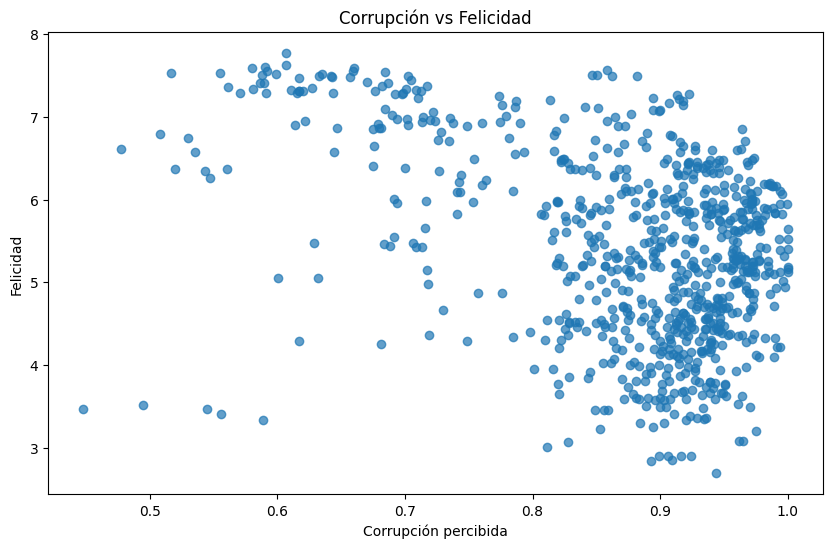

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
df["perceived_corruption"],
df["happiness_score"],
alpha=0.7
)

plt.xlabel("Corrupción percibida")
plt.ylabel("Felicidad")

plt.title("Corrupción vs Felicidad")

plt.show()

Sugiere Relación negativa entre corrupción y felicidad.

In [92]:
# Top países más felices
top_happy = (
df.groupby("country")["happiness_score"]
.mean()
.sort_values(ascending=False)
.head(10)
)

top_happy

country
Denmark        7.5460
Norway         7.5410
Finland        7.5378
Switzerland    7.5114
Iceland        7.5110
Netherlands    7.4046
Canada         7.3506
Sweden         7.3192
New Zealand    7.3130
Australia      7.2762
Name: happiness_score, dtype: float64

In [93]:
# Top corrupción
top_corruption = (
df.groupby("country")["perceived_corruption"]
.mean()
.sort_values(ascending=False)
.head(10)
)

top_corruption

country
Bosnia and Herzegovina    0.998346
Romania                   0.995266
Bulgaria                  0.992216
Moldova                   0.990946
Trinidad and Tobago       0.989075
Indonesia                 0.987093
Portugal                  0.983228
Trinidad & Tobago         0.982500
Lithuania                 0.982325
Ukraine                   0.981614
Name: perceived_corruption, dtype: float64

In [94]:
# Comparación de variables
df[
[
"happiness_score",
"perceived_corruption",
"gdp_per_capita",
"social_support",
"life_expectancy",
"freedom"
]
].mean()

happiness_score         5.379018
perceived_corruption    0.874608
gdp_per_capita          0.916047
social_support          1.078392
life_expectancy         0.612416
freedom                 0.411091
dtype: float64

Insight final del análisis:
Los países con mayor percepción de corrupción tienden a presentar menores niveles de felicidad.

Sin embargo, la felicidad es un fenómeno multidimensional influido por factores económicos, sociales, sanitarios y políticos.

Variables como el PIB per cápita, el apoyo social y la esperanza de vida presentan correlaciones más fuertes con la felicidad que la corrupción por sí sola.

In [95]:
# Guardamos el dataset limpio para SQL
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Gazeb@85",
    database="happiness_corruption_db"
)

df_countries = pd.read_sql_query("SELECT * FROM countries", conn)
df_happiness = pd.read_sql_query("SELECT * FROM happiness_indicators", conn)
df_corruption = pd.read_sql_query("SELECT * FROM corruption_indicators", conn)

conn.close()

df_countries.head()

/var/folders/t3/nrw97mdn40j3lpprlyf3l8ym0000gn/T/ipykernel_96417/303211241.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_countries = pd.read_sql_query("SELECT * FROM countries", conn)
/var/folders/t3/nrw97mdn40j3lpprlyf3l8ym0000gn/T/ipykernel_96417/303211241.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_happiness = pd.read_sql_query("SELECT * FROM happiness_indicators", conn)
/var/folders/t3/nrw97mdn40j3lpprlyf3l8ym0000gn/T/ipykernel_96417/303211241.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df

,country_id,country,region
0,1,Switzerland,Western Europe
1,2,Iceland,Western Europe
2,3,Denmark,Western Europe
3,4,Norway,Western Europe
4,5,Canada,North America


In [96]:
# Verificamos que los datos se hayan cargado correctamente
print("Countries:", df_countries.shape)
print("Happiness:", df_happiness.shape)
print("Corruption:", df_corruption.shape)

df_happiness.head()

Countries: (328, 3)
Happiness: (782, 10)
Corruption: (782, 4)


,happiness_id,country_id,year,happiness_rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity
0,1,1,2015,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678
1,2,2,2015,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630
2,3,3,2015,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139
3,4,4,2015,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699
4,5,5,2015,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811


In [97]:
# Verificamos que los datos se hayan cargado correctamente
countries = (
    df[["country", "region"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

countries["country_id"] = countries.index + 1

countries = countries[
    ["country_id", "country", "region"]
]

countries.head()

,country_id,country,region
0,1,Switzerland,Western Europe
1,2,Iceland,Western Europe
2,3,Denmark,Western Europe
3,4,Norway,Western Europe
4,5,Canada,North America


In [98]:
# Verificamos que los datos se hayan cargado correctamente
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

user = "root"
password = quote_plus("Gazeb@85")
host = "localhost"
port = "3306"
database = "happiness_corruption_db"

engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"
)

with engine.connect() as connection:
    print(connection.execute(text("SELECT DATABASE();")).fetchone())

('happiness_corruption_db',)


In [99]:
!pip install cryptography

Defaulting to user installation because normal site-packages is not writeable


In [100]:
!pip install sqlalchemy pymysql

Defaulting to user installation because normal site-packages is not writeable


In [101]:
import pandas as pd
from sqlalchemy import create_engine
from pathlib import Path

In [102]:
from sqlalchemy import text

with engine.connect() as connection:
    connection.execute(text("SET FOREIGN_KEY_CHECKS = 0"))
    connection.execute(text("TRUNCATE TABLE corruption_indicators"))
    connection.execute(text("TRUNCATE TABLE happiness_indicators"))
    connection.execute(text("TRUNCATE TABLE countries"))
    connection.execute(text("SET FOREIGN_KEY_CHECKS = 1"))
    connection.commit()

print("Tablas vaciadas correctamente")

Tablas vaciadas correctamente


In [103]:
countries.to_sql("countries", engine, if_exists="append", index=False)
happiness_indicators.to_sql("happiness_indicators", engine, if_exists="append", index=False)
corruption_indicators.to_sql("corruption_indicators", engine, if_exists="append", index=False)

print("Datos cargados correctamente en MySQL")

Datos cargados correctamente en MySQL


In [104]:
pd.read_sql("SELECT COUNT(*) AS total FROM countries", engine)

,total
0,328


In [105]:
pd.read_sql("SELECT COUNT(*) AS total FROM happiness_indicators", engine)

,total
0,782


In [106]:
pd.read_sql("SELECT COUNT(*) AS total FROM corruption_indicators", engine)

,total
0,782


COMPROBACION TRANSFERENCIA PYTHON - SQL

In [7]:
import os

# Ver qué hay en la carpeta actual
print(os.listdir("."))

# Ver si existe sql-database
if os.path.exists("sql-database"):
    print("\nContenido de sql-database:")
    print(os.listdir("sql-database"))

['01_data_cleaning.ipynb', '.DS_Store']


In [8]:
import os

# Ver dónde está el notebook exactamente
print("Estoy aquí:", os.getcwd())

# Ver todo lo que hay en la carpeta actual
print("\nContenido actual:")
print(os.listdir("."))

# Buscar sql-database en varias rutas posibles
rutas = [
    "sql-database/Data",
    "../sql-database/Data",
    "../../sql-database/Data",
]

for ruta in rutas:
    if os.path.exists(ruta):
        print(f"\n✓ Encontrado en: {ruta}")
        print(os.listdir(ruta))
        break
    else:
        print(f"✗ No está en: {ruta}")

Estoy aquí: /Users/gabrielbohorquez/Desktop/Ironhack/Semana_3/PROYECTO/happiness-corruption-analysis/sql-database/notebooks

Contenido actual:
['01_data_cleaning.ipynb', '.DS_Store']
✗ No está en: sql-database/Data
✗ No está en: ../sql-database/Data

✓ Encontrado en: ../../sql-database/Data
['.DS_Store', 'clean', 'raw']


In [9]:
import os
print("raw:", os.listdir("../../sql-database/Data/raw"))
print("clean:", os.listdir("../../sql-database/Data/clean"))

raw: ['.DS_Store', '2019.csv', '2018.csv', '2015.csv', '2016.csv', '2017.csv']
clean: ['.DS_Store', 'countries.csv', 'happiness_clean_full.csv', 'corruption_indicators.csv', 'happiness_indicators.csv']


In [10]:
import pandas as pd
from pathlib import Path

# Ruta correcta
DATA_DIR = Path("../../sql-database/Data/clean")

# Cargar CSV
countries = pd.read_csv(DATA_DIR / "countries.csv")
happiness_indicators = pd.read_csv(DATA_DIR / "happiness_indicators.csv")
corruption_indicators = pd.read_csv(DATA_DIR / "corruption_indicators.csv")

# Verificar filas
print("Filas CSV:")
print("countries:", len(countries))
print("happiness_indicators:", len(happiness_indicators))
print("corruption_indicators:", len(corruption_indicators))

Filas CSV:
countries: 328
happiness_indicators: 782
corruption_indicators: 782


In [11]:
import os

# Buscar archivos .db o .sql en el proyecto
for ruta, carpetas, archivos in os.walk("../../"):
    for archivo in archivos:
        if archivo.endswith(".db") or archivo.endswith(".sql"):
            print(os.path.join(ruta, archivo))

../../sql-database/sql/Import_data.sql


In [12]:
# Leer el contenido del archivo SQL
with open("../../sql-database/sql/Import_data.sql", "r") as f:
    contenido = f.read()
print(contenido)

SELECT COUNT(*) FROM countries;

SELECT COUNT(*) FROM happiness_indicators;

SELECT COUNT(*) FROM corruption_indicators;

SELECT * FROM countries LIMIT 10;
SELECT * FROM happiness_indicators LIMIT 10;
SELECT * FROM corruption_indicators LIMIT 10;

SELECT
c.country,
h.year,
h.happiness_score,
ci.perceived_corruption
FROM happiness_indicators h
JOIN countries c
ON h.country_id = c.country_id
JOIN corruption_indicators ci
ON h.happiness_id = ci.happiness_id
LIMIT 20;


VERIFICACION DE TRANSFERENCIA DE DATOS DE PYTHON A SQL COMPROBADA

In [16]:
import pandas as pd
from pathlib import Path
from sqlalchemy import create_engine

# Conexión
DB_PATH = "../../sql-database/happiness.db"
engine = create_engine(f"sqlite:///{DB_PATH}")

# Cargar CSV
DATA_DIR = Path("../../sql-database/Data/clean")
countries = pd.read_csv(DATA_DIR / "countries.csv")
happiness_indicators = pd.read_csv(DATA_DIR / "happiness_indicators.csv")
corruption_indicators = pd.read_csv(DATA_DIR / "corruption_indicators.csv")

# Transferir a SQL
countries.to_sql("countries", engine, if_exists="replace", index=False)
happiness_indicators.to_sql("happiness_indicators", engine, if_exists="replace", index=False)
corruption_indicators.to_sql("corruption_indicators", engine, if_exists="replace", index=False)
print("Tablas creadas ✓")

# Verificar
countries_sql = pd.read_sql("SELECT * FROM countries", engine)
happiness_sql = pd.read_sql("SELECT * FROM happiness_indicators", engine)
corruption_sql = pd.read_sql("SELECT * FROM corruption_indicators", engine)

print("\n=== FILAS CSV vs SQL ===")
print(f"countries:             CSV={len(countries)}  →  SQL={len(countries_sql)}")
print(f"happiness_indicators:  CSV={len(happiness_indicators)}  →  SQL={len(happiness_sql)}")
print(f"corruption_indicators: CSV={len(corruption_indicators)}  →  SQL={len(corruption_sql)}")

print("\n=== COINCIDEN? ===")
print(f"countries:             {len(countries) == len(countries_sql)}")
print(f"happiness_indicators:  {len(happiness_indicators) == len(happiness_sql)}")
print(f"corruption_indicators: {len(corruption_indicators) == len(corruption_sql)}")

Tablas creadas ✓

=== FILAS CSV vs SQL ===
countries:             CSV=328  →  SQL=328
happiness_indicators:  CSV=782  →  SQL=782
corruption_indicators: CSV=782  →  SQL=782

=== COINCIDEN? ===
countries:             True
happiness_indicators:  True
corruption_indicators: True
